# Hispasonic EDA — Exploratory Data Analysis

**Source:** `../data/processed/hispasonic_unified.csv`  
**Goal:** Deep exploratory analysis focused on temporal evolution, price dynamics, brand and city patterns, and correlation groups  
**Figures:** Saved automatically to `../reports/figures/`

---

## Analysis plan
1. Dataset overview
2. Temporal evolution — listing volume and price trends over time
3. Price analysis — distribution, outliers, listing type breakdown
4. Brand analysis — top brands, price per brand, brand evolution over time
5. Geographic analysis — top cities, price by city, city activity over time
6. Engagement (`seen`) — distribution, seen vs price, seen by brand
7. Correlation matrix — all numeric variables
8. Cross-group analysis — brand × city, brand × time heatmaps

## 1. Imports, config and figure helper

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH    = '../data/processed/hispasonic_unified.csv'
FIGURES_DIR  = '../reports/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

TOP_N = 15  # number of brands / cities to show in ranked charts

def savefig(name):
    """Save current figure to reports/figures/ and display inline."""
    path = os.path.join(FIGURES_DIR, f'{name}.png')
    plt.savefig(path, dpi=150)
    print(f'Saved → {path}')
    plt.show()

print('Setup complete.')

Setup complete.


## 2. Load dataset

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['published', 'expire', 'date_scrapped'])

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Date range (date_scrapped): {df["date_scrapped"].min().date()} → {df["date_scrapped"].max().date()}')
print(f'Unique brands: {df["synt_brand"].nunique()}')
print(f'Unique cities: {df["city"].nunique()}')
print()
df.head()

Shape: (5962, 17)
Columns: ['urgent', 'buy', 'change', 'sell', 'price', 'gift', 'search', 'repair', 'parts', 'synt_brand', 'description', 'city', 'published', 'expire', 'date_scrapped', 'seen', 'source_file']
Date range (date_scrapped): 2022-08-26 → 2024-05-26
Unique brands: 249
Unique cities: 49



,urgent,buy,change,sell,price,gift,search,repair,parts,synt_brand,description,city,published,expire,date_scrapped,seen,source_file
0,0,0,0,1,350,0,0,0,0,dreadbox,dreadbox nyx v1,Valencia,2022-05-08,2022-09-23,2022-08-26,668,2022_08_26.csv
1,0,0,0,1,350,0,0,0,0,modal electronics,cobalt 5s,Castellón,2022-07-25,2022-09-23,2022-08-26,312,2022_08_26.csv
2,0,0,0,1,900,0,0,0,0,moog,moog little phatty stage 2,Baleares,2021-07-10,2022-09-28,2022-08-26,548,2022_08_26.csv
3,0,0,0,1,420,0,0,0,0,doepfer,último precio doepfer a-100 6u,Málaga,2022-07-01,2022-08-30,2022-08-26,272,2022_08_26.csv
4,0,0,0,1,480,0,0,0,0,mpc,mpc live ssd 250 envío incluido,Albacete,2022-08-26,2022-10-25,2022-08-26,78,2022_08_26.csv


## 3. Temporal evolution

Saved → ../reports/figures/01_listing_volume_over_time.png


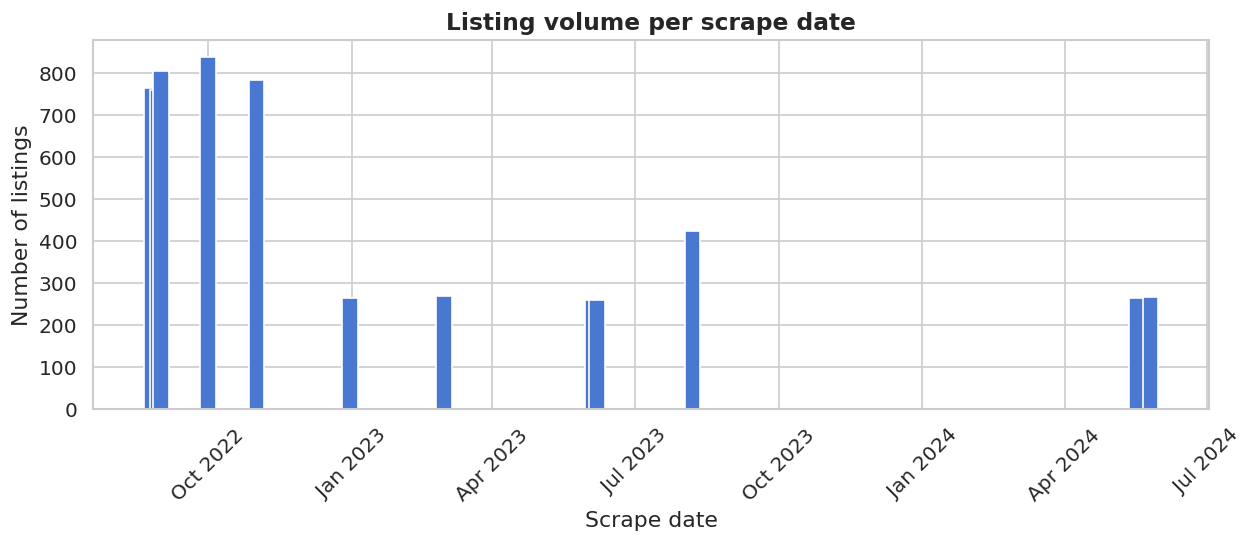

In [3]:
# ── 3a. Listing volume per scrape date ────────────────────────────────────
vol = df.groupby('date_scrapped').size().reset_index(name='listings')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(vol['date_scrapped'], vol['listings'], width=10, color=sns.color_palette('muted')[0])
ax.set_title('Listing volume per scrape date', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('Number of listings')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
savefig('01_listing_volume_over_time')

Saved → ../reports/figures/02_price_evolution_over_time.png


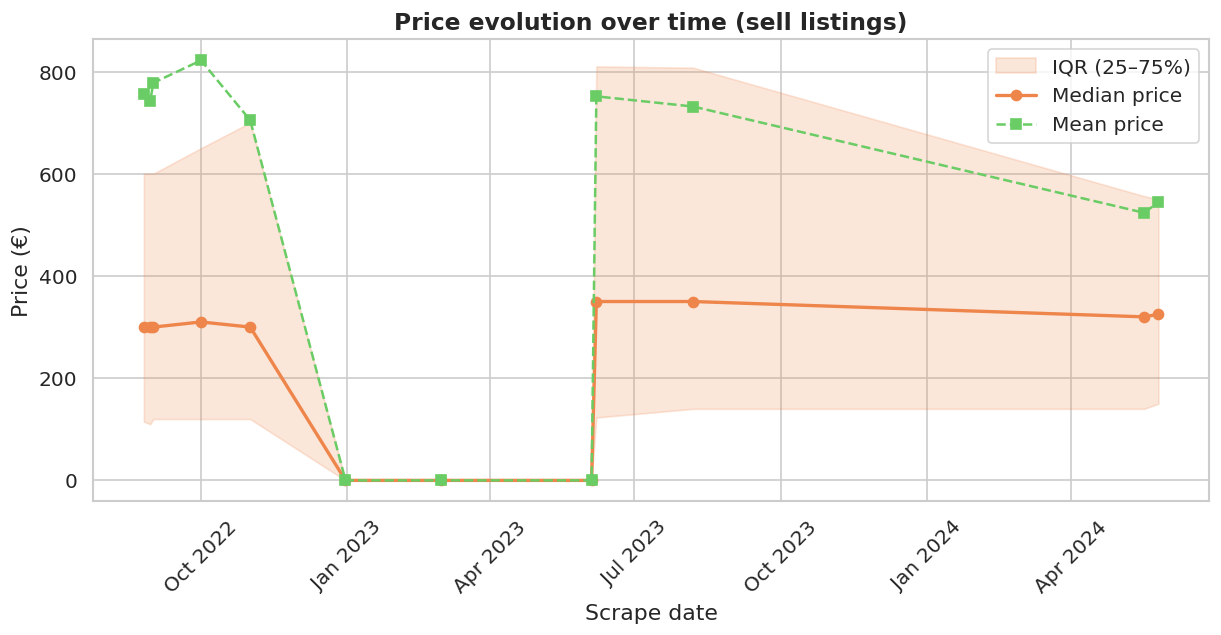

In [4]:
# ── 3b. Median and mean price evolution over time ─────────────────────────
df_sell = df[df['sell'] == 1].copy()

price_time = df_sell.groupby('date_scrapped')['price'].agg(
    median='median', mean='mean', q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(price_time['date_scrapped'], price_time['q25'], price_time['q75'],
                alpha=0.2, label='IQR (25–75%)', color=sns.color_palette('muted')[1])
ax.plot(price_time['date_scrapped'], price_time['median'], marker='o', label='Median price',
        color=sns.color_palette('muted')[1], linewidth=2)
ax.plot(price_time['date_scrapped'], price_time['mean'], marker='s', linestyle='--',
        label='Mean price', color=sns.color_palette('muted')[2], linewidth=1.5)
ax.set_title('Price evolution over time (sell listings)', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('Price (€)')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend()
savefig('02_price_evolution_over_time')

Saved → ../reports/figures/03_listing_type_share_over_time.png


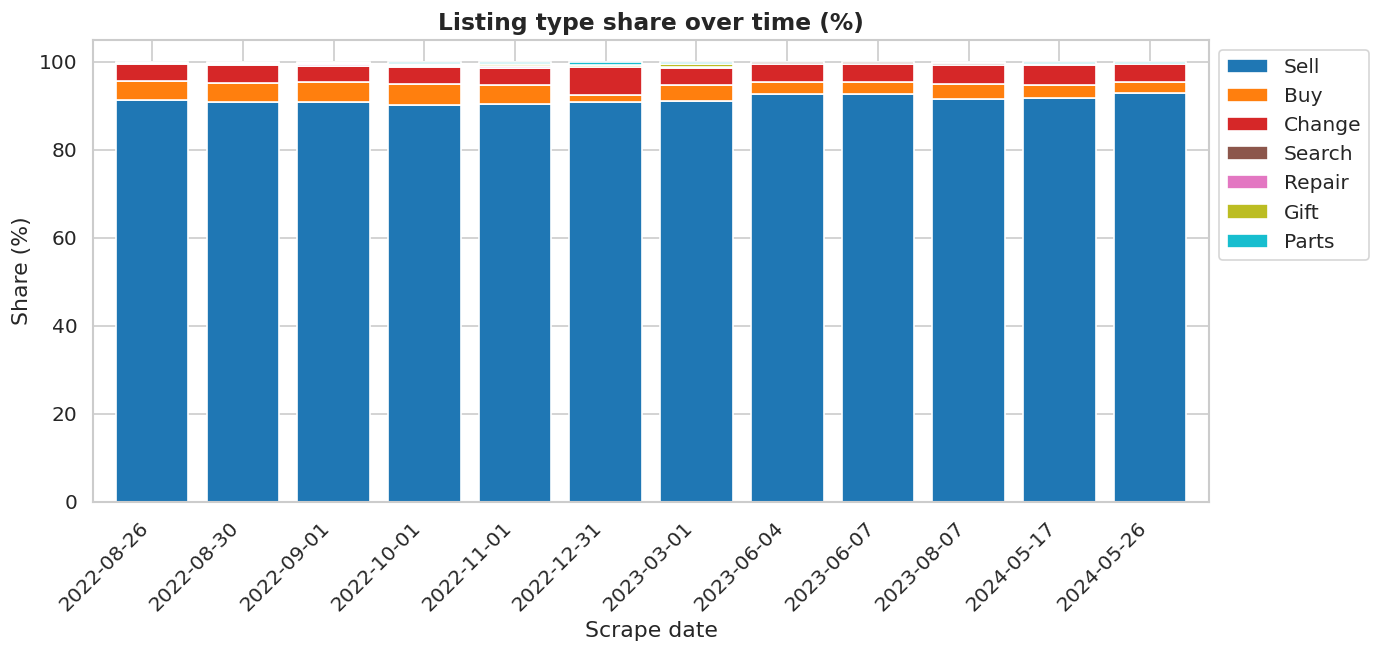

In [5]:
# ── 3c. Listing type share over time ──────────────────────────────────────
type_map = {'sell': 'Sell', 'buy': 'Buy', 'change': 'Change', 'search': 'Search',
            'repair': 'Repair', 'gift': 'Gift', 'parts': 'Parts'}

type_time = df.groupby('date_scrapped')[list(type_map.keys())].sum()
type_time_pct = type_time.div(type_time.sum(axis=1), axis=0) * 100
type_time_pct.columns = type_map.values()

fig, ax = plt.subplots(figsize=(12, 5))
type_time_pct.plot(kind='bar', stacked=True, ax=ax,
                   colormap='tab10', width=0.8)
ax.set_title('Listing type share over time (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('Share (%)')
ax.set_xticklabels([str(d.date()) for d in type_time_pct.index], rotation=45, ha='right')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
savefig('03_listing_type_share_over_time')

## 4. Price analysis

Saved → ../reports/figures/04_price_distribution.png


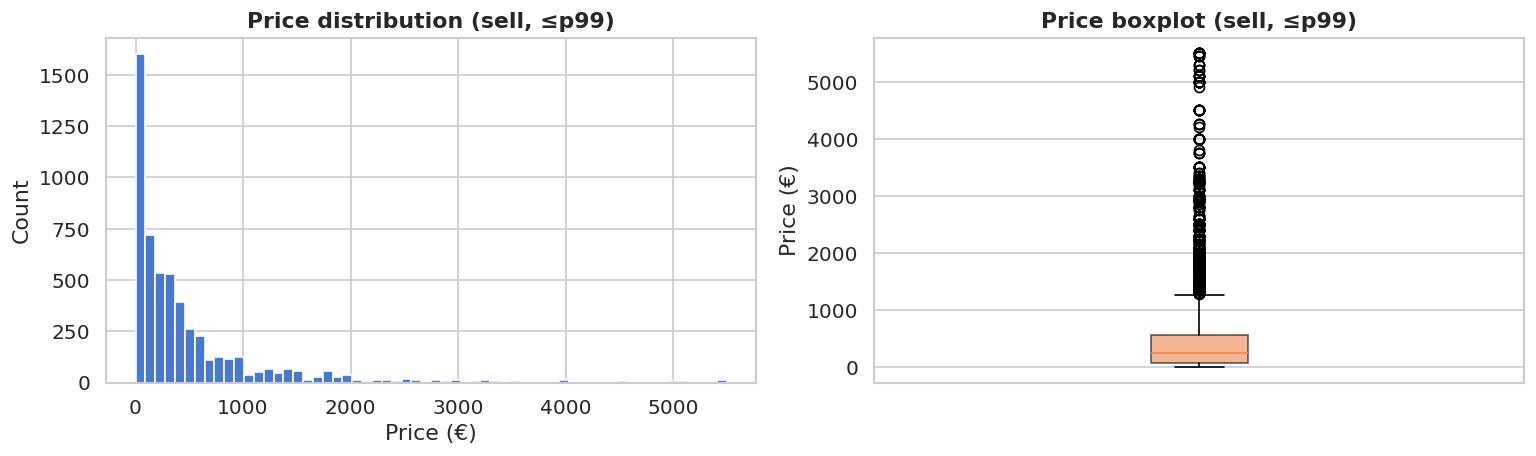

In [6]:
# ── 4a. Price distribution (sell listings, remove extreme outliers) ───────
prices = df_sell['price'].dropna()
p99 = prices.quantile(0.99)
prices_clipped = prices[prices <= p99]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(prices_clipped, bins=60, color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_title('Price distribution (sell, ≤p99)', fontweight='bold')
axes[0].set_xlabel('Price (€)')
axes[0].set_ylabel('Count')

axes[1].boxplot(prices_clipped, vert=True, patch_artist=True,
                boxprops=dict(facecolor=sns.color_palette('muted')[1], alpha=0.6))
axes[1].set_title('Price boxplot (sell, ≤p99)', fontweight='bold')
axes[1].set_ylabel('Price (€)')
axes[1].set_xticks([])

plt.tight_layout()
savefig('04_price_distribution')

In [7]:
# ── 4b. Price summary stats ───────────────────────────────────────────────
print('=== Price summary (sell listings) ===')
print(prices.describe().round(2))
print(f'\nOutliers above p99 (>{p99:.0f}€): {(prices > p99).sum()} listings')

=== Price summary (sell listings) ===
count      5480.00
mean        636.64
std        3205.27
min           0.00
25%          75.00
50%         250.00
75%         550.00
max      111111.00
Name: price, dtype: float64

Outliers above p99 (>5500€): 47 listings


## 5. Brand analysis

Saved → ../reports/figures/05_top_brands_by_listings.png


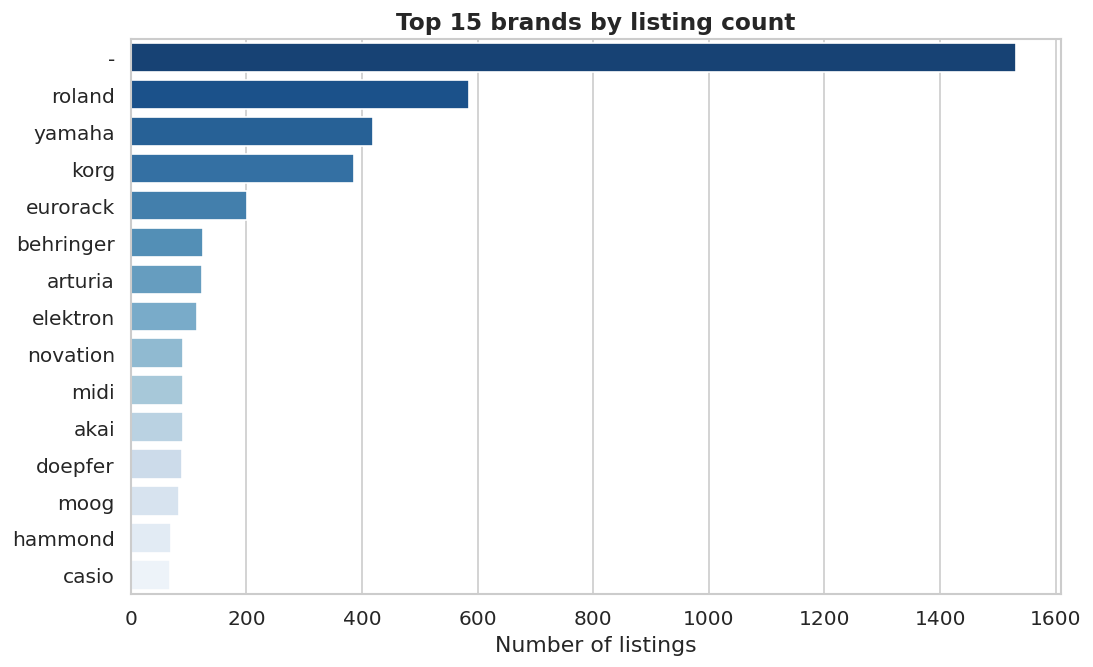

In [8]:
# ── 5a. Top brands by listing count ──────────────────────────────────────
top_brands = df['synt_brand'].value_counts().head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_brands.values, y=top_brands.index, hue=top_brands.index, ax=ax,
            palette='Blues_r')
ax.set_title(f'Top {TOP_N} brands by listing count', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of listings')
ax.set_ylabel('')
savefig('05_top_brands_by_listings')

Saved → ../reports/figures/06_median_price_per_brand.png


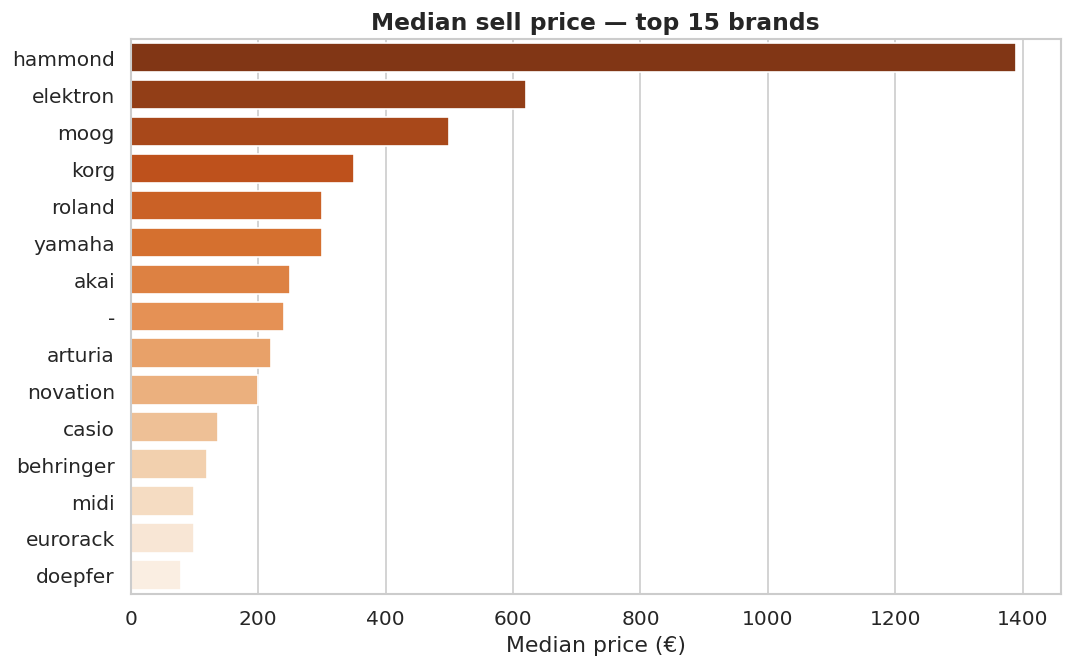

In [9]:
# ── 5b. Median price per top brand ────────────────────────────────────────
brand_price = (
    df_sell[df_sell['synt_brand'].isin(top_brands.index)]
    .groupby('synt_brand')['price']
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=brand_price.values, y=brand_price.index, hue=brand_price.index, ax=ax, palette='Oranges_r')
ax.set_title(f'Median sell price — top {TOP_N} brands', fontsize=14, fontweight='bold')
ax.set_xlabel('Median price (€)')
ax.set_ylabel('')
savefig('06_median_price_per_brand')

Saved → ../reports/figures/07_brand_evolution_over_time.png


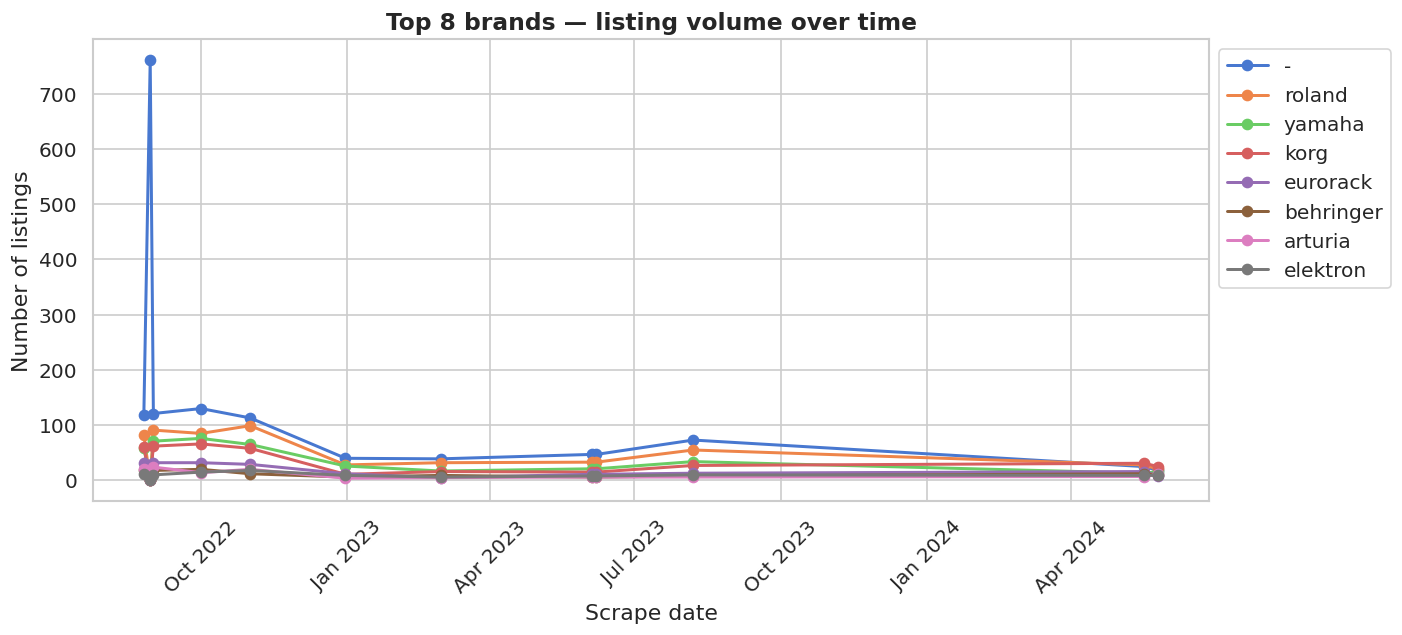

In [10]:
# ── 5c. Brand evolution over time (top 8 brands) ─────────────────────────
top8 = df['synt_brand'].value_counts().head(8).index.tolist()
brand_time = (
    df[df['synt_brand'].isin(top8)]
    .groupby(['date_scrapped', 'synt_brand'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
for brand in top8:
    if brand in brand_time.columns:
        ax.plot(brand_time.index, brand_time[brand], marker='o', label=brand, linewidth=1.8)
ax.set_title('Top 8 brands — listing volume over time', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('Number of listings')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
savefig('07_brand_evolution_over_time')

Saved → ../reports/figures/08_brand_time_heatmap.png


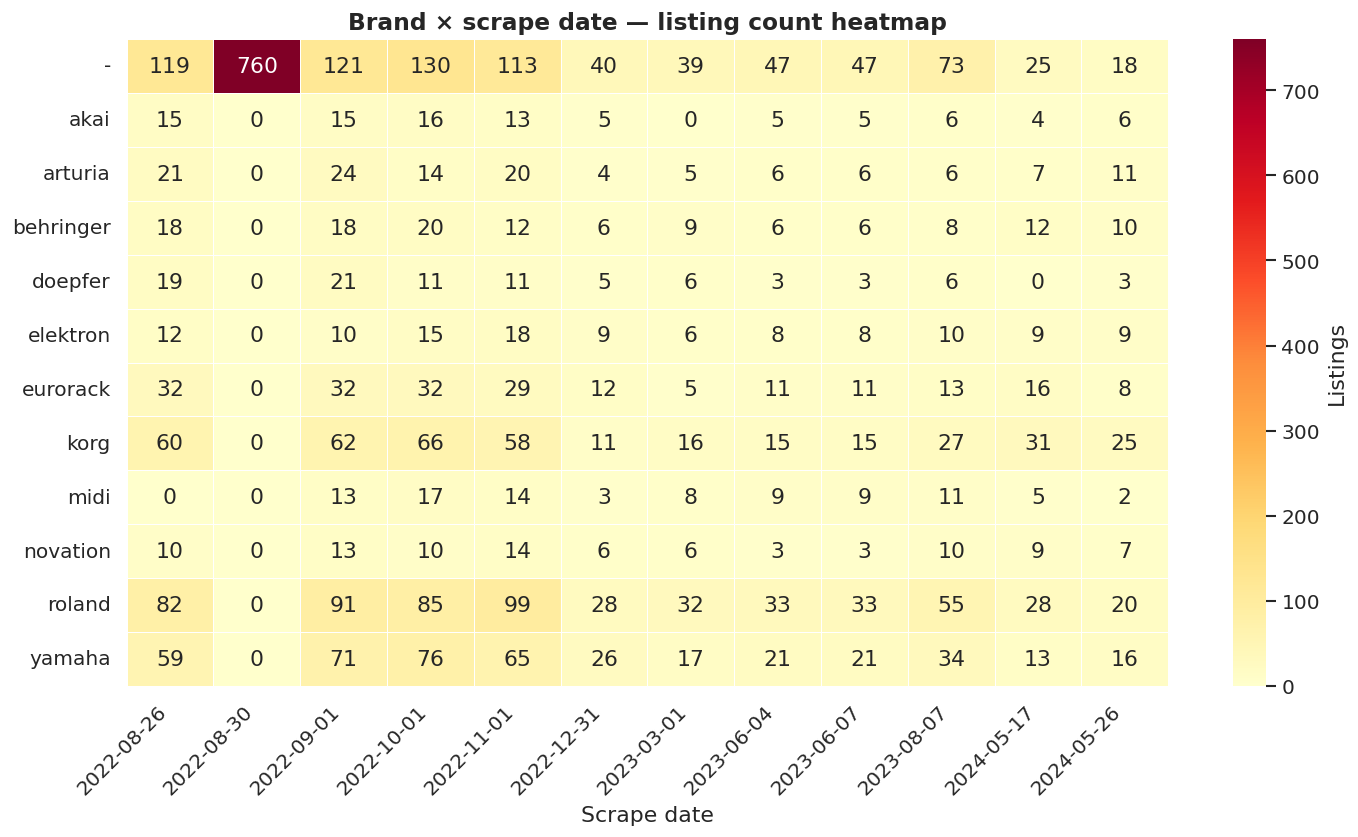

In [11]:
# ── 5d. Brand × time heatmap (listing count) ──────────────────────────────
top12 = df['synt_brand'].value_counts().head(12).index.tolist()
heatmap_data = (
    df[df['synt_brand'].isin(top12)]
    .groupby(['synt_brand', 'date_scrapped'])
    .size()
    .unstack(fill_value=0)
)
heatmap_data.columns = [str(c.date()) for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Listings'})
ax.set_title('Brand × scrape date — listing count heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
savefig('08_brand_time_heatmap')

## 6. Geographic analysis

Saved → ../reports/figures/09_top_cities_by_listings.png


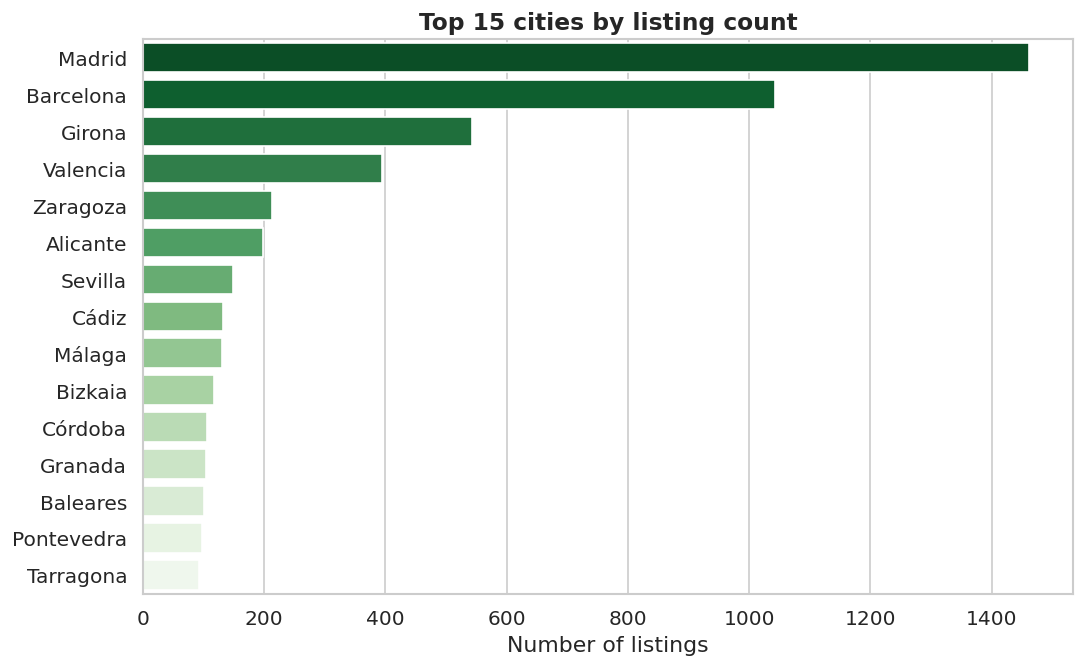

In [12]:
# ── 6a. Top cities by listing count ───────────────────────────────────────
top_cities = df['city'].value_counts().head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, hue=top_cities.index, ax=ax, palette='Greens_r')
ax.set_title(f'Top {TOP_N} cities by listing count', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of listings')
ax.set_ylabel('')
savefig('09_top_cities_by_listings')

Saved → ../reports/figures/10_median_price_per_city.png


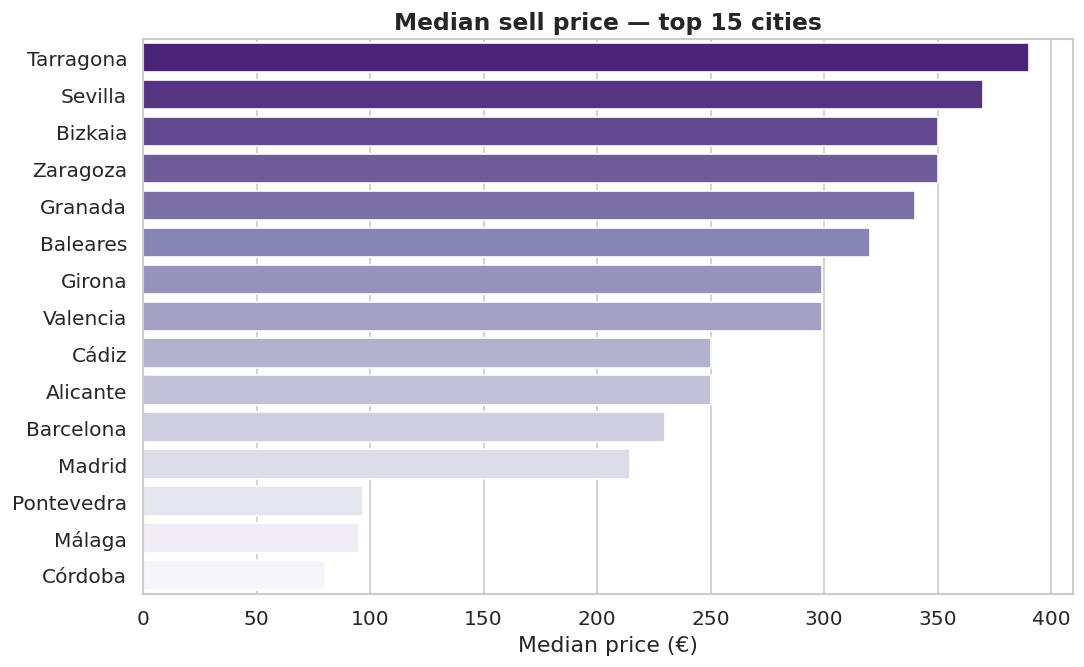

In [13]:
# ── 6b. Median sell price by top city ────────────────────────────────────
city_price = (
    df_sell[df_sell['city'].isin(top_cities.index)]
    .groupby('city')['price']
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=city_price.values, y=city_price.index, hue=city_price.index,ax=ax, palette='Purples_r')
ax.set_title(f'Median sell price — top {TOP_N} cities', fontsize=14, fontweight='bold')
ax.set_xlabel('Median price (€)')
ax.set_ylabel('')
savefig('10_median_price_per_city')

Saved → ../reports/figures/11_city_evolution_over_time.png


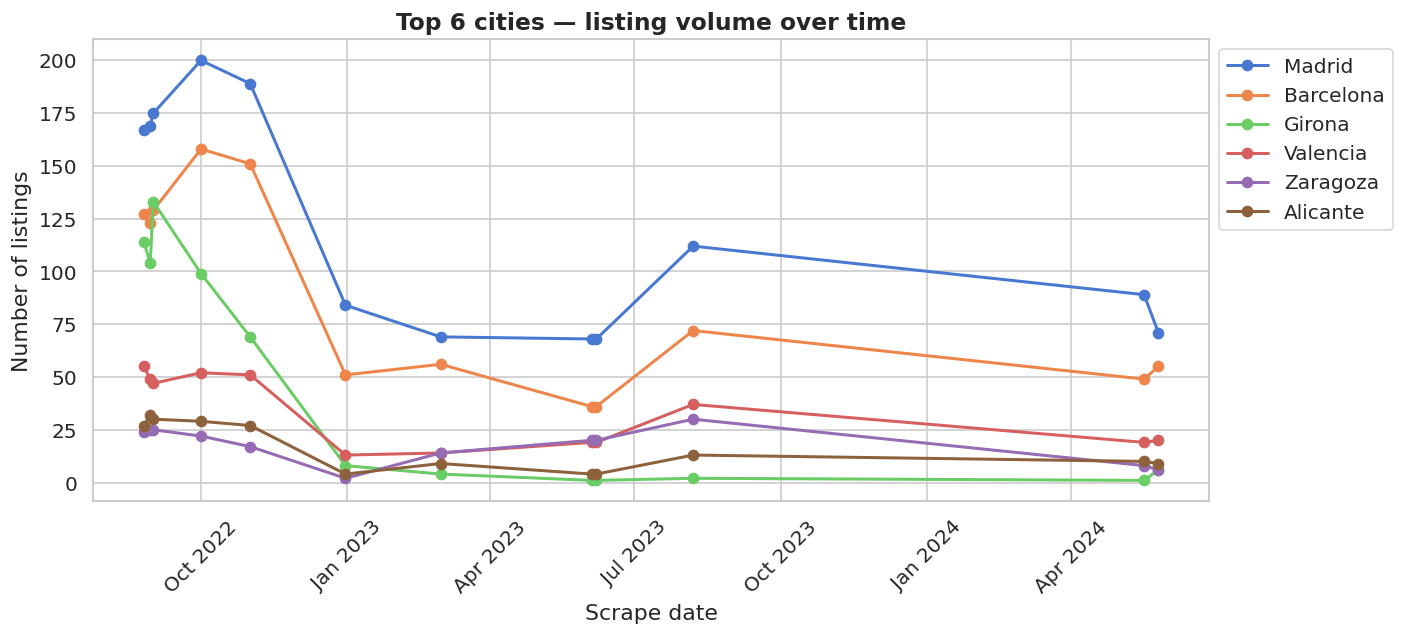

In [14]:
# ── 6c. City activity over time (top 6) ───────────────────────────────────
top6_cities = df['city'].value_counts().head(6).index.tolist()
city_time = (
    df[df['city'].isin(top6_cities)]
    .groupby(['date_scrapped', 'city'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
for city in top6_cities:
    if city in city_time.columns:
        ax.plot(city_time.index, city_time[city], marker='o', label=city, linewidth=1.8)
ax.set_title('Top 6 cities — listing volume over time', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('Number of listings')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
savefig('11_city_evolution_over_time')

## 7. Engagement — `seen` analysis

Saved → ../reports/figures/12_seen_distribution.png


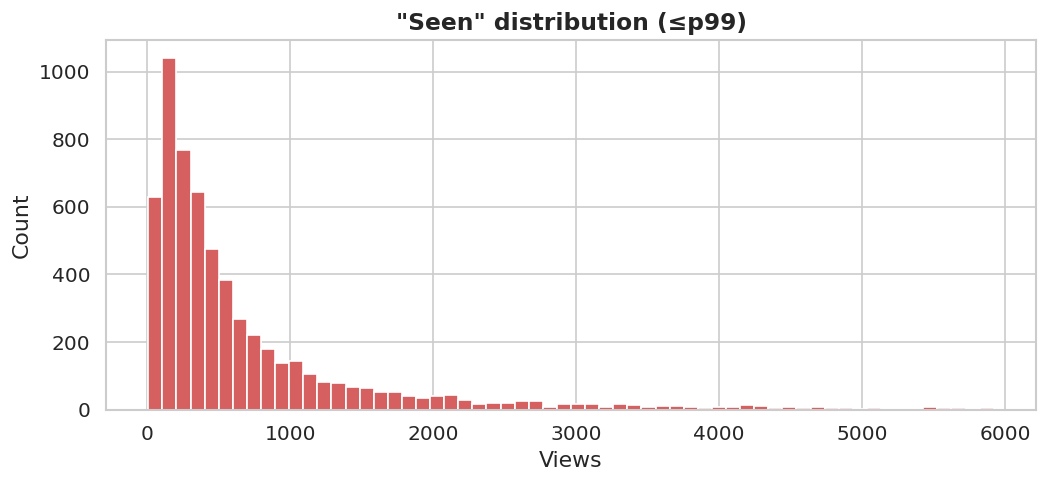

In [15]:
# ── 7a. Seen distribution ─────────────────────────────────────────────────
seen = df['seen'].dropna()
seen_p99 = seen.quantile(0.99)
seen_clipped = seen[seen <= seen_p99]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(seen_clipped, bins=60, color=sns.color_palette('muted')[3], edgecolor='white')
ax.set_title('"Seen" distribution (≤p99)', fontsize=14, fontweight='bold')
ax.set_xlabel('Views')
ax.set_ylabel('Count')
savefig('12_seen_distribution')

Saved → ../reports/figures/13_price_vs_seen_scatter.png


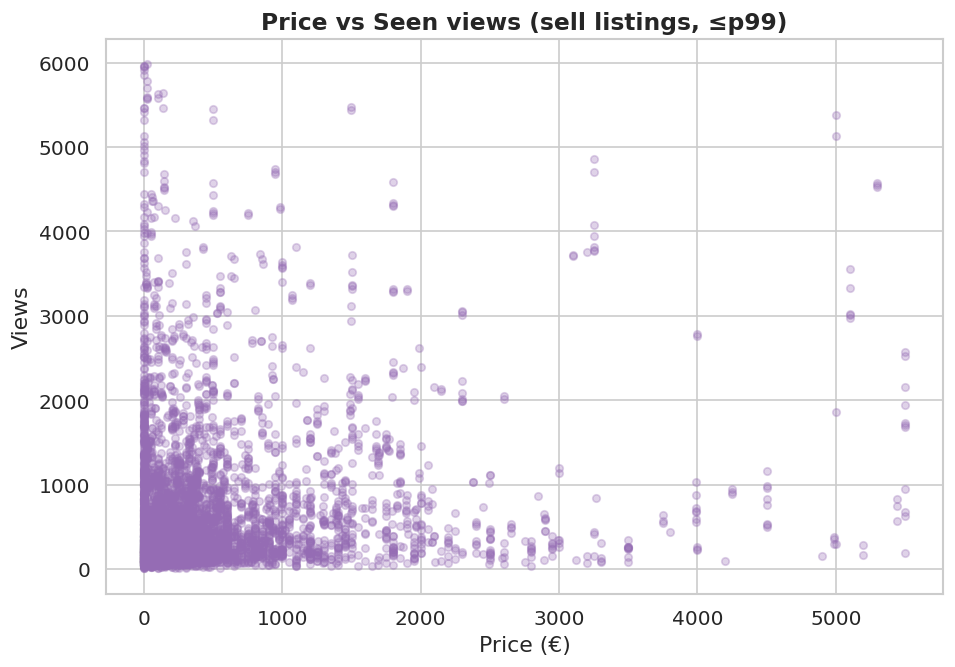

In [16]:
# ── 7b. Seen vs price scatter ─────────────────────────────────────────────
scatter_df = df_sell[['price', 'seen']].dropna()
scatter_df = scatter_df[
    (scatter_df['price'] <= scatter_df['price'].quantile(0.99)) &
    (scatter_df['seen']  <= scatter_df['seen'].quantile(0.99))
]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(scatter_df['price'], scatter_df['seen'], alpha=0.3, s=20,
           color=sns.color_palette('muted')[4])
ax.set_title('Price vs Seen views (sell listings, ≤p99)', fontsize=14, fontweight='bold')
ax.set_xlabel('Price (€)')
ax.set_ylabel('Views')
savefig('13_price_vs_seen_scatter')

Saved → ../reports/figures/14_median_seen_per_brand.png


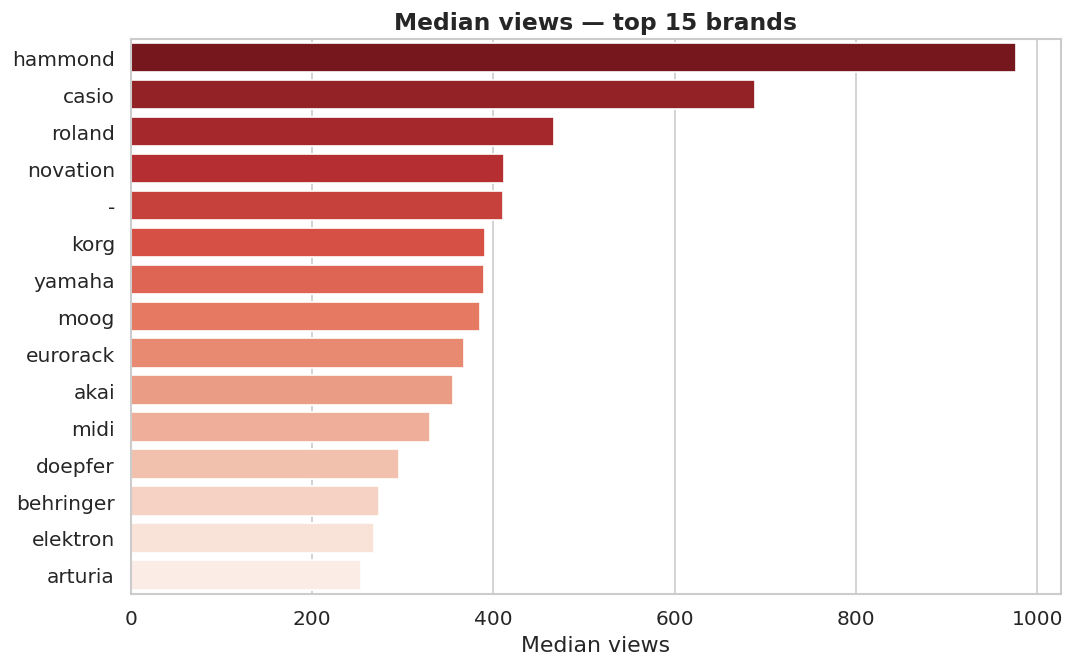

In [17]:
# ── 7c. Median seen by top brand ──────────────────────────────────────────
brand_seen = (
    df[df['synt_brand'].isin(top_brands.index)]
    .groupby('synt_brand')['seen']
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=brand_seen.values, y=brand_seen.index, hue=brand_seen.index, ax=ax, palette='Reds_r')
ax.set_title(f'Median views — top {TOP_N} brands', fontsize=14, fontweight='bold')
ax.set_xlabel('Median views')
ax.set_ylabel('')
savefig('14_median_seen_per_brand')

## 8. Correlation matrix

Saved → ../reports/figures/15_correlation_matrix.png


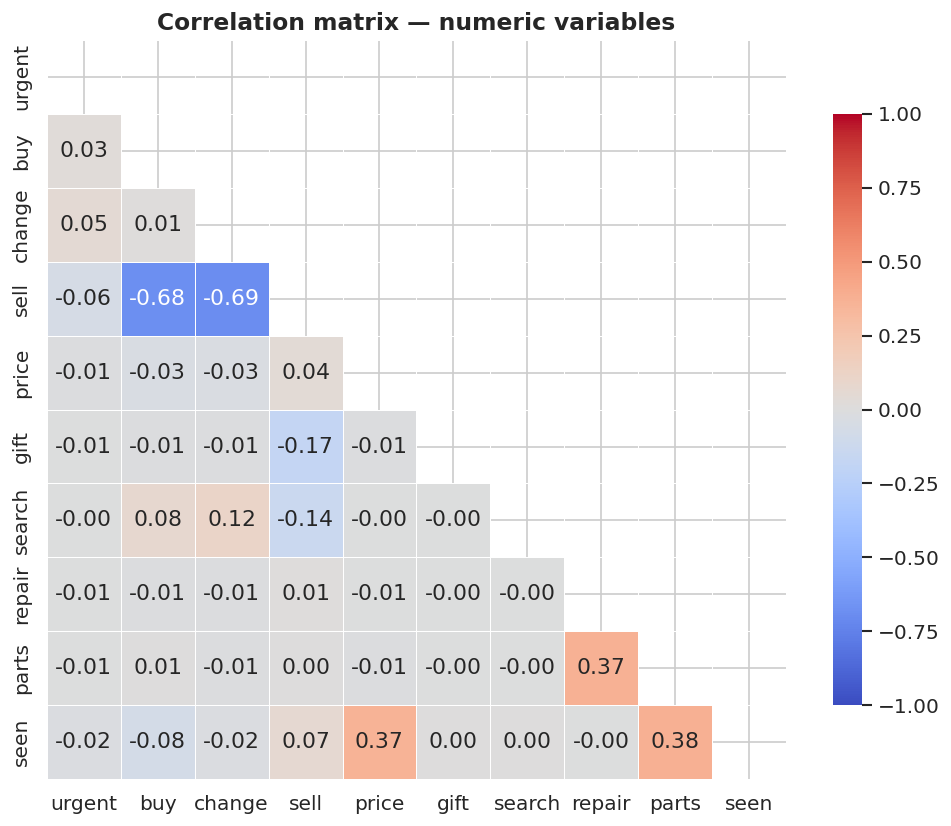

In [18]:
# ── 8a. Full numeric correlation heatmap ─────────────────────────────────
num_cols = ['urgent', 'buy', 'change', 'sell', 'price', 'gift',
            'search', 'repair', 'parts', 'seen']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation matrix — numeric variables', fontsize=14, fontweight='bold')
savefig('15_correlation_matrix')

## 9. Cross-group analysis

Saved → ../reports/figures/16_brand_city_heatmap.png


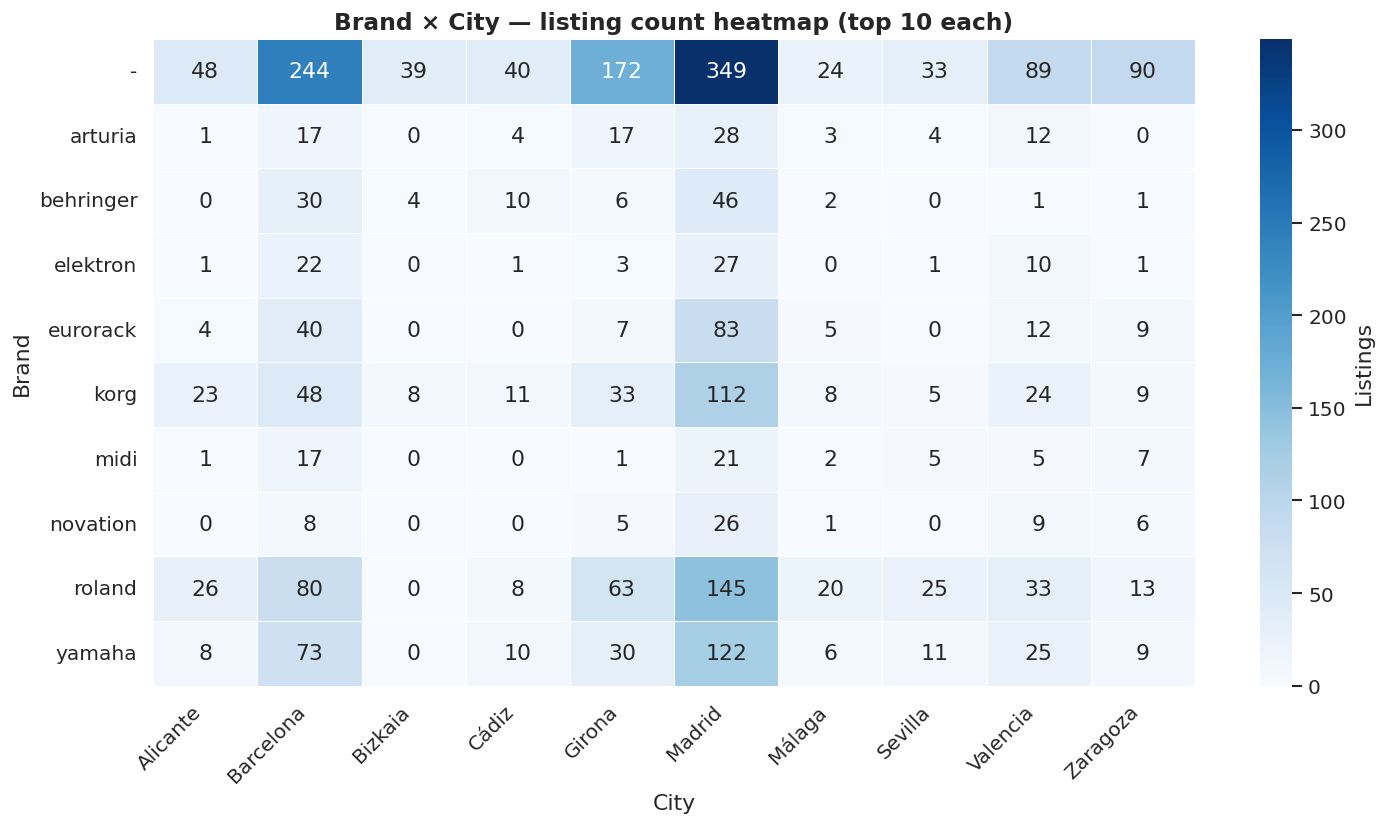

In [19]:
# ── 9a. Brand × city heatmap (listing count, top 10 each) ─────────────────
top10_brands = df['synt_brand'].value_counts().head(10).index.tolist()
top10_cities = df['city'].value_counts().head(10).index.tolist()

cross = (
    df[df['synt_brand'].isin(top10_brands) & df['city'].isin(top10_cities)]
    .groupby(['synt_brand', 'city'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Listings'})
ax.set_title('Brand × City — listing count heatmap (top 10 each)', fontsize=14, fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Brand')
plt.xticks(rotation=45, ha='right')
savefig('16_brand_city_heatmap')

Saved → ../reports/figures/17_price_by_brand_and_type.png


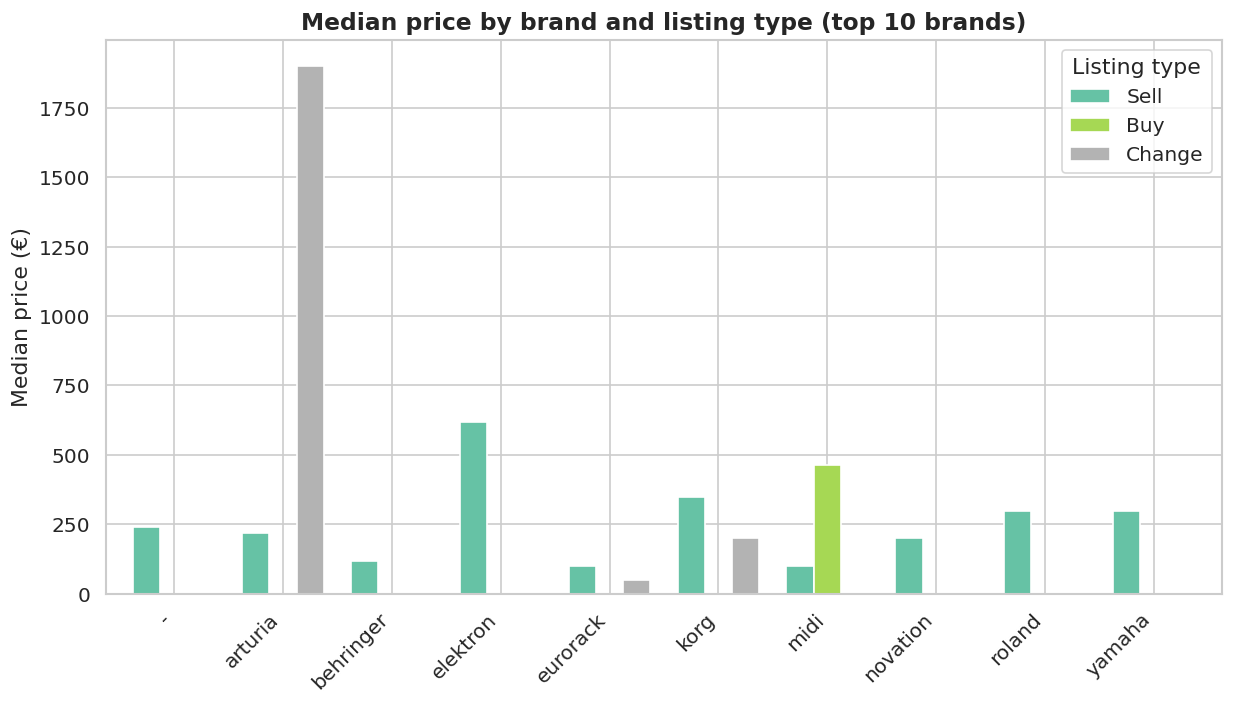

In [20]:
# ── 9b. Median price by brand × listing type ──────────────────────────────
type_cols   = ['sell', 'buy', 'change']
price_pivot = []

for t in type_cols:
    sub = df[(df[t] == 1) & (df['synt_brand'].isin(top10_brands))]
    med = sub.groupby('synt_brand')['price'].median().rename(t.capitalize())
    price_pivot.append(med)

price_pivot_df = pd.concat(price_pivot, axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
price_pivot_df.plot(kind='bar', ax=ax, colormap='Set2', width=0.75)
ax.set_title('Median price by brand and listing type (top 10 brands)', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Median price (€)')
plt.xticks(rotation=45, ha='right')
ax.legend(title='Listing type')
savefig('17_price_by_brand_and_type')

Saved → ../reports/figures/18_price_evolution_by_brand.png


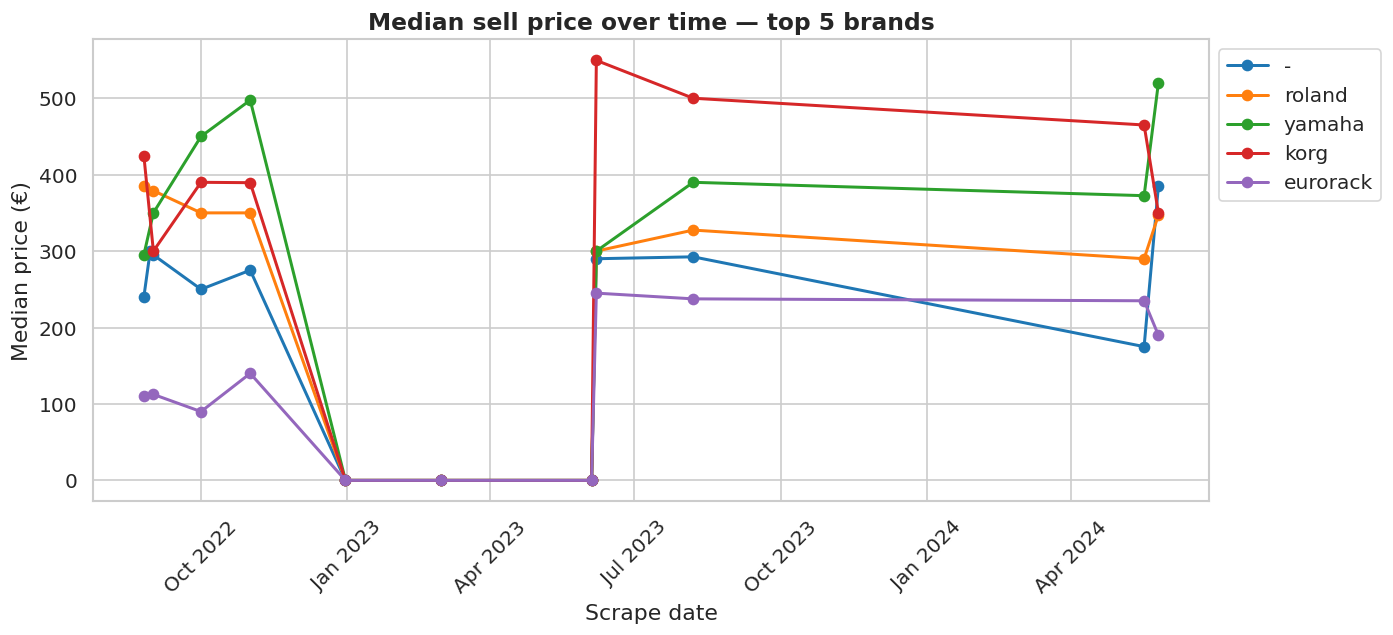

In [21]:
# ── 9c. Price evolution by top 5 brands over time ────────────────────────
top5 = df_sell['synt_brand'].value_counts().head(5).index.tolist()

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('tab10', n_colors=5)

for i, brand in enumerate(top5):
    sub = df_sell[df_sell['synt_brand'] == brand].groupby('date_scrapped')['price'].median()
    ax.plot(sub.index, sub.values, marker='o', label=brand,
            color=palette[i], linewidth=1.8)

ax.set_title('Median sell price over time — top 5 brands', fontsize=14, fontweight='bold')
ax.set_xlabel('Scrape date')
ax.set_ylabel('Median price (€)')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
savefig('18_price_evolution_by_brand')

## 10. Summary

In [22]:
figs = sorted(os.listdir(FIGURES_DIR))
print(f'{len(figs)} figures saved to {os.path.abspath(FIGURES_DIR)}:')
for f in figs:
    if f.endswith('.png'):
        print(f'  {f}')

19 figures saved to /home/ion/dev/github/hispasonic/reports/figures:
  01_listing_volume_over_time.png
  02_price_evolution_over_time.png
  03_listing_type_share_over_time.png
  04_price_distribution.png
  05_top_brands_by_listings.png
  06_median_price_per_brand.png
  07_brand_evolution_over_time.png
  08_brand_time_heatmap.png
  09_top_cities_by_listings.png
  10_median_price_per_city.png
  11_city_evolution_over_time.png
  12_seen_distribution.png
  13_price_vs_seen_scatter.png
  14_median_seen_per_brand.png
  15_correlation_matrix.png
  16_brand_city_heatmap.png
  17_price_by_brand_and_type.png
  18_price_evolution_by_brand.png
